# Titanic Dataset - Exploratory Data Analysis (EDA)

**Intern:** Amna Shahid  
**Company:** Neurofive Solutions  
**Task:** Week 1 - Exploratory Data Analysis using Pandas and NumPy

### Objective
The objective of this notebook is to explore the Titanic dataset, understand its structure, identify missing values, classify features into numerical and categorical types, and summarize the initial observations before applying machine learning models.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\User51023\Desktop\ML\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (891, 12)


In [6]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
numerical = df.select_dtypes(include=['int64', 'float64'])

print("Numerical Columns:")
print(numerical.columns.tolist())

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [8]:
categorical = df.select_dtypes(include=['object'])

print("Categorical Columns:")
print(categorical.columns.tolist())

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## Data Story

The Titanic dataset contains **891 rows and 12 columns**, representing passenger information such as age, gender, ticket class, fare, and survival status. During the initial exploration, I found that the **Age**, **Cabin**, and **Embarked** columns contain missing values, with the **Cabin** column having the highest number of missing entries. The dataset contains both numerical and categorical features, making it suitable for preprocessing and machine learning tasks. The statistical summary provides useful insights into variables such as age and fare. This exploratory analysis helps understand the dataset before building predictive models.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

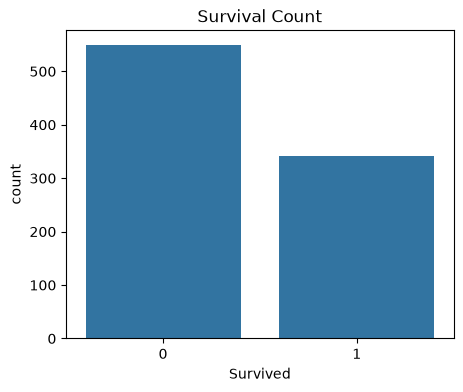

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

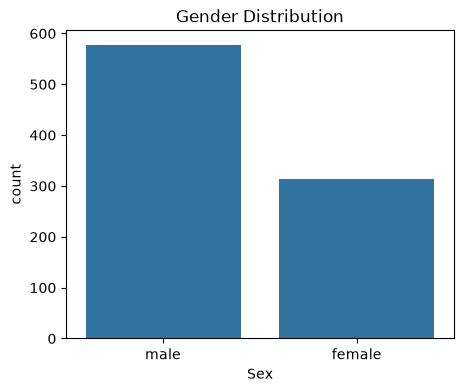

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

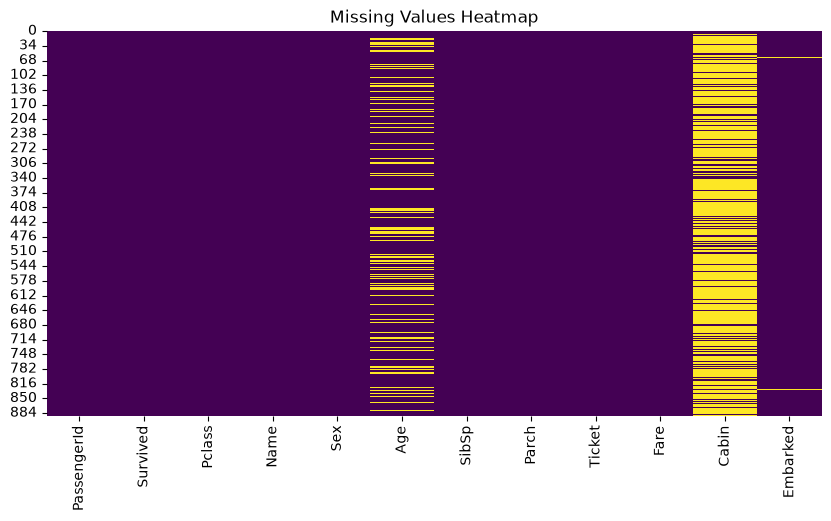

In [12]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Task 2 - Data Cleaning & Visualization

In this task, we clean the Titanic dataset by handling missing values,
identify outliers, and visualize important patterns using Matplotlib and Seaborn.

These steps help prepare the data before machine learning and allow us
to better understand the dataset.

In [13]:
# Checking missing values before cleaning

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Handling Missing Values

The Titanic dataset contains missing values mainly in **Age**, **Cabin**, and **Embarked**.

### Choice:

- **Age:** Missing values are replaced with the median because age is numerical and the median is less affected by extreme values.
- **Embarked:** Missing values are replaced with the most frequent value (mode) since it is categorical.
- **Cabin:** More than 75% of the values are missing, so this column is dropped because it would contribute very little useful information.

In [14]:
# Fill missing values in Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing values in Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin only if it still exists
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# Check remaining missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Detecting Outliers

A boxplot is used to detect outliers.

Here we examine the **Fare** column because ticket fares vary greatly and may contain unusually high values.

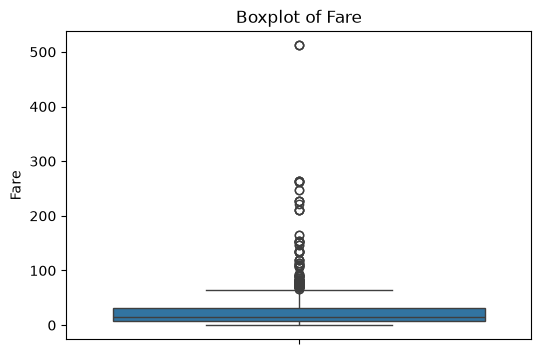

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.boxplot(y=df['Fare'])

plt.title("Boxplot of Fare")

plt.show()

# Data Visualization

The following visualizations help understand the distribution of data,
relationships between variables, and potential factors affecting survival.

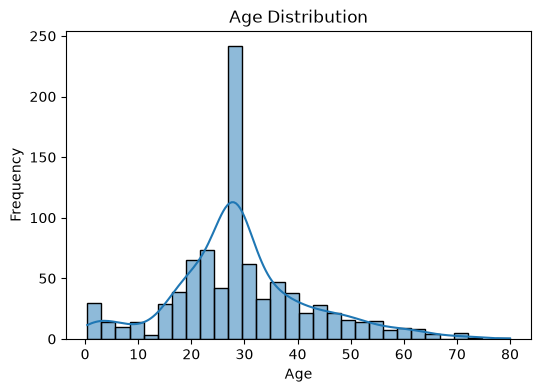

In [16]:
plt.figure(figsize=(6,4))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

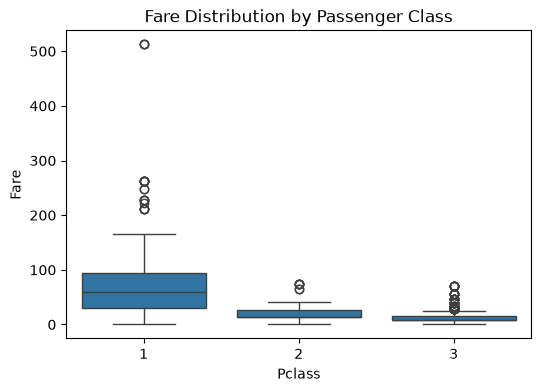

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['Pclass'], y=df['Fare'])

plt.title("Fare Distribution by Passenger Class")

plt.show()

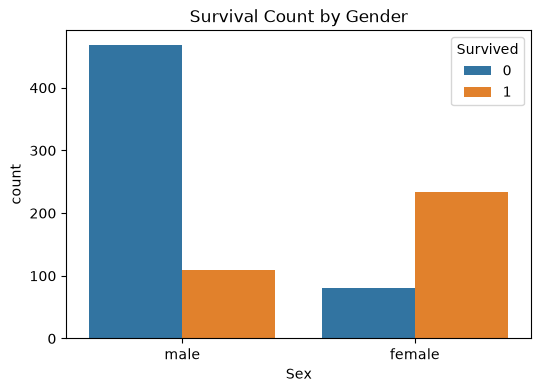

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Gender")

plt.show()

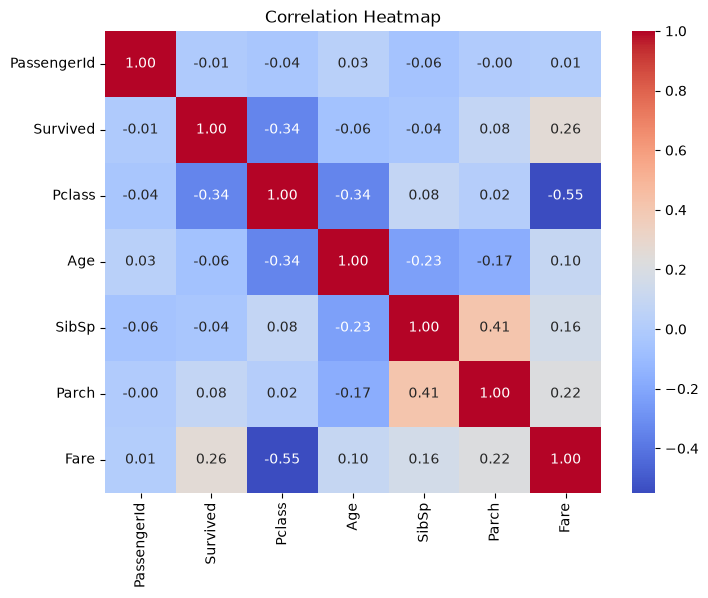

In [19]:
# Select only numerical columns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

# Which feature do you think most affects survival, and why?

From the visualizations, **Sex** appears to have the strongest impact on survival.

The bar chart shows that a much higher proportion of female passengers survived compared to male passengers. This aligns with the historical "women and children first" evacuation policy followed during the Titanic disaster.

Passenger class (Pclass) also influences survival, as first-class passengers generally had better access to lifeboats. However, gender shows the clearest and strongest relationship with survival.

In [20]:
# Final dataset information after cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


# Conclusion

In this task, the dataset was cleaned by handling missing values and removing a highly incomplete column. Outliers were identified using a boxplot, and four different visualizations were created to better understand the data.

The analysis suggests that **Sex** is the most influential feature affecting passenger survival, followed by passenger class.

# Titanic Survival Prediction using Logistic Regression

In this task, I built my first machine learning classification model.

The objective is to predict whether a passenger survived the Titanic disaster based on different passenger features.

The workflow includes:
- Preparing the dataset
- Encoding categorical variables
- Splitting data into training and testing sets
- Training a Logistic Regression model
- Evaluating the model using Accuracy Score and Confusion Matrix

In [21]:
# Import required libraries

import pandas as pd
import numpy as np

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Plotting
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv(r"C:\Users\User51023\Desktop\ML\train.csv")

In [23]:
# Remove columns that are not useful for prediction

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Fill missing values

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Check remaining missing values

print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## Data Preparation

Before training the model, unnecessary columns such as PassengerId, Name, Ticket, and Cabin were removed because they do not directly help predict passenger survival.

Missing values in the Age column were replaced with the median, while missing values in Embarked were replaced with the most frequent category.

In [24]:
# Convert categorical variables into numerical values

df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# Display first five rows

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Why Encoding?

Machine learning models cannot understand text values such as "male", "female", or "S".

Therefore, categorical columns were converted into numerical columns using pd.get_dummies().

In [25]:
# Features

X = df.drop("Survived", axis=1)

# Target

y = df["Survived"]

print(X.head())

   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


In [26]:
# Split data into training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


## Why Train-Test Split?

The dataset is divided into two parts.

- Training data is used to teach the model.
- Testing data is used to evaluate how well the model performs on unseen data.

This helps measure whether the model can generalize to new data.

In [27]:
# Create Logistic Regression model

model = LogisticRegression(max_iter=1000)

# Train the model

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Logistic Regression

Logistic Regression is a classification algorithm that predicts the probability of belonging to a particular class.

In this project, it predicts whether a passenger survived or not.

In [28]:
# Predict survival

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [29]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


## Model Accuracy

Accuracy measures how many predictions made by the model were correct.

A higher accuracy indicates better model performance.

[[90 15]
 [19 55]]


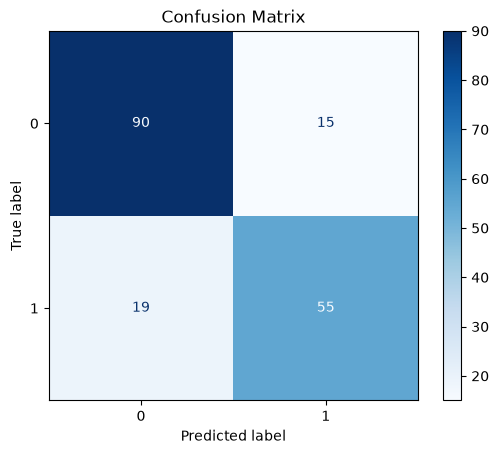

In [30]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

# Display confusion matrix

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## Confusion Matrix Explanation

The confusion matrix shows how well the model classified passengers.

- True Positives: Correctly predicted passengers who survived.
- True Negatives: Correctly predicted passengers who did not survive.
- False Positives: Predicted survival, but the passenger did not survive.
- False Negatives: Predicted death, but the passenger actually survived.

The goal is to maximize correct predictions while minimizing incorrect ones.

# Task 5 – Model Evaluation and Hyperparameter Tuning

**Machine Learning Internship – Neurofive Solutions**

**Intern:** Amna Shahid

### Task Overview

In this task, I evaluated the Logistic Regression model using Precision, Recall, and F1-score. I also improved the model using **GridSearchCV** to find the best hyperparameters and compared the tuned model with the original model.

In [33]:
# Make predictions using the original Logistic Regression model

y_pred = model.predict(X_test)

## Classification Report

Accuracy alone does not always provide a complete picture of model performance.

The classification report includes:

- Precision
- Recall
- F1-score

These metrics help evaluate how well the model predicts each class.

In [34]:
from sklearn.metrics import classification_report

print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Why Accuracy Can Be Misleading

Accuracy measures the percentage of correct predictions.

However, in an imbalanced dataset, one class may appear much more frequently than another.

For example, if 90% of passengers survived and a model predicts that everyone survived, it would achieve 90% accuracy while completely failing to identify passengers who did not survive.

Therefore, Precision, Recall, and F1-score provide a better understanding of model performance because they evaluate how well each class is predicted.

## Hyperparameter Tuning using GridSearchCV

Instead of manually guessing the best settings, GridSearchCV automatically tests different combinations of hyperparameters and selects the best-performing model.

For Logistic Regression, the following hyperparameters are tuned:

- C (Regularization strength)
- Solver

In [36]:
from sklearn.model_selection import GridSearchCV

# Parameters to test

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

In [37]:
print("Best Parameters Found:")

print(grid.best_params_)

print("\nBest Cross Validation Score:")

print(grid.best_score_)

Best Parameters Found:
{'C': 1, 'solver': 'liblinear'}

Best Cross Validation Score:
0.7962966610853935


## Evaluate the Tuned Model

In [38]:
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score

original_accuracy = accuracy_score(y_test, y_pred)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Original Accuracy :", original_accuracy)

print("Tuned Accuracy :", tuned_accuracy)

Original Accuracy : 0.8100558659217877
Tuned Accuracy : 0.7821229050279329


In [40]:
print("Classification Report for Tuned Model\n")

print(classification_report(y_test, y_pred_tuned))

Classification Report for Tuned Model

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



# Model Comparison

The following table compares the original Logistic Regression model with the tuned model obtained using GridSearchCV.

In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        round(original_accuracy,3),
        round(tuned_accuracy,3)
    ]
})

comparison

,Model,Accuracy
0,Original Logistic Regression,0.810
1,Tuned Logistic Regression,0.782


# Conclusion

The Logistic Regression model was evaluated using Precision, Recall, and F1-score in addition to accuracy.

GridSearchCV was used to tune two hyperparameters (C and solver). The tuned model was then compared with the original model.

Hyperparameter tuning helps identify better model settings systematically rather than relying on trial and error.